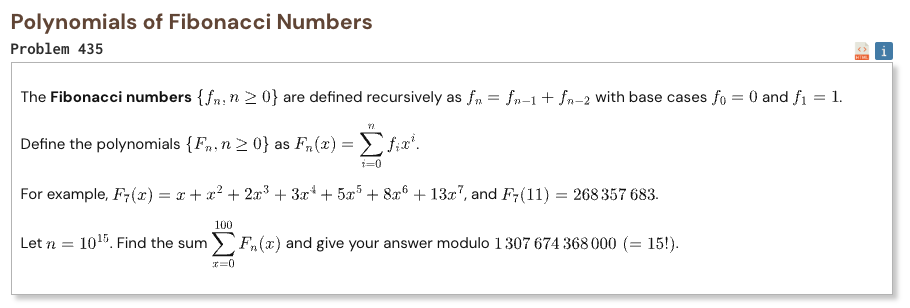

## Initial approach

-   treat each value of x separately from 0 to 100
-   keep track of the current Fibonacci term, the next Fibonacci term and the running polynomial sum
-   these three values can be updated together with a small matrix
-   use matrix exponentiation so we can jump directly to the trillionth scale index without looping through every Fibonacci number
-   reduce every matrix calculation modulo 15 factorial to keep the numbers small
-   repeat the calculation for every x from 0 through 100
-   add all polynomial values together and take the modulo one final time

In [1]:
MOD = 1307674368000
N = 10**15

def mat_mul(a, b):
    return [
        [
            sum(a[i][k] * b[k][j] for k in range(3)) % MOD
            for j in range(3)
        ]
        for i in range(3)
    ]

def mat_vec_mul(a, v):
    return [
        sum(a[i][j] * v[j] for j in range(3)) % MOD
        for i in range(3)
    ]

def polynomial_sum(n, x):
    matrix = [
        [0, x, 0],
        [x, x, 0],
        [0, x, 1]
    ]

    state = [0, 1, 0]

    while n > 0:
        if n % 2 == 1:
            state = mat_vec_mul(matrix, state)

        matrix = mat_mul(matrix, matrix)
        n //= 2

    return state[2]

In [2]:
%%time

result = 0

for x in range(101):
    result += polynomial_sum(N, x)
    result %= MOD

print("Result:", result)

Result: 252541322550
CPU times: user 36.8 ms, sys: 1.09 ms, total: 37.9 ms
Wall time: 37.1 ms
